# Differential Expression Analysis: GSE28379 (Familial Alzheimer's PS2-N141 iPSCs)

This notebook re-analyzes the GDS4141 / GSE28379 dataset (Yagi et al., 2011),
comparing control iPSCs to Presenilin-2 (PSEN2) N141-mutant iPSCs.

**Correction note (this version):** the earlier version of this notebook mislabeled
one of the four samples. `GSM701543` was renamed `control2` and averaged into the
control group, but the dataset's own metadata (`!Sample_characteristics_ch1` in the
series matrix file) identifies it as `PD01-25 iPSC`, described as
`"disease state: Sporadic Parkinson's disease"`; a Parkinson's patient sample, not
a healthy control replicate. That means the original "control vs. Alzheimer's" result
was quietly comparing (1 real control + 1 Parkinson's sample) against the two PS2
mutants.

This version fixes the labels and is explicit about what the dataset can and can't
support statistically.

In [4]:
# We only have four arrays total in this dataset, so every step below has to be
# read with that in mind, this is exploratory, not a well-powered experiment.
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/USER/Documents/BioInformatics/Bioinformatics_projects/intro_To_Bioinformatics/GSE28379_series_matrix.txt", sep="\t", comment="!", index_col=0)
df.head()

,GSM701542,GSM701543,GSM701544,GSM701545
ID_REF,,,,
1007_s_at,615.52540,739.778000,720.900400,735.847500
1053_at,319.87120,654.391660,730.687200,515.430500
117_at,20.04304,32.151443,14.417517,24.944078
121_at,239.84415,171.029600,137.311610,176.759780
1255_g_at,155.14342,335.751860,177.997860,128.042790


In [5]:
# Real sample identities, copied from the file's own metadata rows
# (!Sample_title / !Sample_characteristics_ch1), not guessed from column order:
#   GSM701542 -> "201B7 iPSC"      -> the actual healthy control
#   GSM701543 -> "PD01-25 iPSC"    -> Sporadic Parkinson's disease patient iPSC 
#   GSM701544 -> "PS2-1 iPSC"      -> Alzheimer's (PSEN2 N141) mutant clone 1
#   GSM701545 -> "PS2-2 iPSC"      -> Alzheimer's (PSEN2 N141) mutant clone 2

df = df.rename(columns={
    'GSM701542': 'control',
    'GSM701543': 'sporadic_pd',
    'GSM701544': 'ad_mutant1',
    'GSM701545': 'ad_mutant2',
})
df.head()

,control,sporadic_pd,ad_mutant1,ad_mutant2
ID_REF,,,,
1007_s_at,615.52540,739.778000,720.900400,735.847500
1053_at,319.87120,654.391660,730.687200,515.430500
117_at,20.04304,32.151443,14.417517,24.944078
121_at,239.84415,171.029600,137.311610,176.759780
1255_g_at,155.14342,335.751860,177.997860,128.042790


In [6]:
df.describe()

,control,sporadic_pd,ad_mutant1,ad_mutant2
count,54675.000000,54675.000000,54675.000000,54675.000000
mean,311.163554,324.680869,293.984405,234.041640
std,973.062209,1026.411176,951.423063,854.320162
min,0.098684,0.040403,0.053092,0.036289
25%,10.888680,9.469739,7.973378,6.638893
50%,38.069134,35.693405,29.521608,24.667880
75%,179.445000,179.470150,155.781465,115.830295
max,13434.690000,13528.281000,13031.392000,13826.742000


In [7]:
df.isnull().any().any()

np.False_

In [8]:
# log2 stabilizes the variance across this wide a range of expression values,
# same as the original analysis.
df_log = np.log2(df + 1)
df_log.describe()

,control,sporadic_pd,ad_mutant1,ad_mutant2
count,54675.000000,54675.000000,54675.000000,54675.000000
mean,5.570519,5.504588,5.297840,5.021360
std,2.762567,2.842117,2.842290,2.721586
min,0.135777,0.057143,0.074632,0.051426
25%,3.571517,3.388154,3.165651,2.933364
50%,5.287957,5.197449,4.931759,4.681892
75%,7.495415,7.495616,7.292611,6.868271
max,13.713783,13.723798,13.669814,13.755278


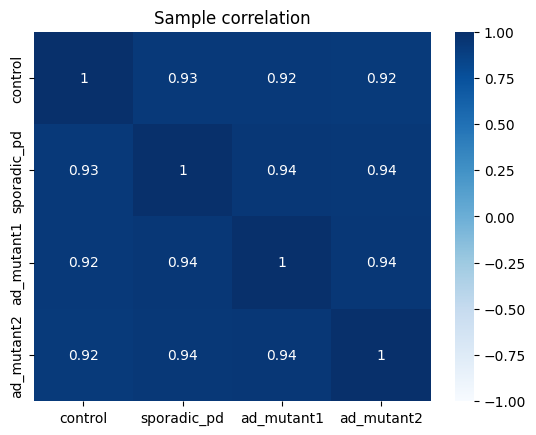

Correlation of sporadic_pd with control:  0.9292
Correlation of sporadic_pd with ad_mutant1: 0.9440
Correlation of sporadic_pd with ad_mutant2: 0.9365


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# With the labels, this heatmap shows that:
# sporadic_pd correlates more strongly with the AD-mutant samples than with the
# real control (see the printed values below the plot)

corr = df_log.corr(numeric_only=True)
sns.heatmap(corr, cmap='Blues', annot=True, vmin=-1, vmax=1)
plt.title("Sample correlation")
plt.show()

print("Correlation of sporadic_pd with control:  %.4f" % corr.loc['sporadic_pd', 'control'])
print("Correlation of sporadic_pd with ad_mutant1: %.4f" % corr.loc['sporadic_pd', 'ad_mutant1'])
print("Correlation of sporadic_pd with ad_mutant2: %.4f" % corr.loc['sporadic_pd', 'ad_mutant2'])

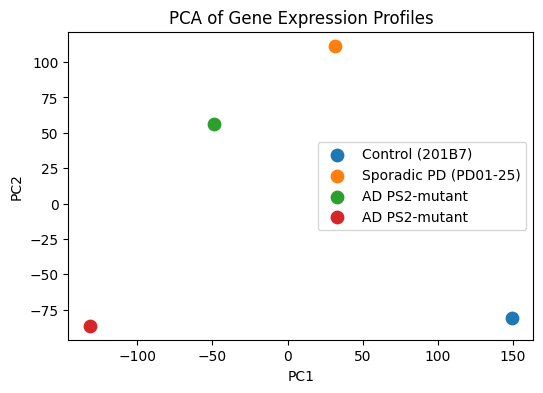

In [10]:
from sklearn.decomposition import PCA

# PCA of Gene Expression Profiles
sample_labels = {
    "control": "Control (201B7)",
    "sporadic_pd": "Sporadic PD (PD01-25)",
    "ad_mutant1": "AD PS2-mutant",
    "ad_mutant2": "AD PS2-mutant",
}

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_log.T)

plt.figure(figsize=(6, 4))
for i, sample in enumerate(df_log.columns):
    label = sample_labels[sample]
    plt.scatter(pca_result[i, 0], pca_result[i, 1], label=label, s=80)
plt.legend()
plt.title("PCA of Gene Expression Profiles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Differential expression

This section reports **plain log2 fold-change** between
the one control array and the mean of the two AD-mutant arraysstically validated.

In [11]:
mutant_cols = ['ad_mutant1', 'ad_mutant2']
df_log['mean_mutant'] = df_log[mutant_cols].mean(axis=1)
df_log['log2FC'] = df_log['mean_mutant'] - df_log['control']

ranked = df_log.reindex(df_log['log2FC'].abs().sort_values(ascending=False).index)
top_candidates = ranked[['control', 'ad_mutant1', 'ad_mutant2', 'log2FC']].head(20)
top_candidates

,control,ad_mutant1,ad_mutant2,log2FC
ID_REF,,,,
229552_at,9.284116,2.129000,1.604582,-7.417325
227062_at,11.070820,5.676401,1.904406,-7.280417
204475_at,0.759884,11.463686,3.522159,6.733039
221577_x_at,12.032800,5.774311,5.411992,-6.439648
225239_at,13.236275,7.723426,6.159211,-6.294957
243221_at,11.921128,6.265426,5.053977,-6.261427
206762_at,7.369547,1.034771,1.563510,-6.070406
235075_at,7.283925,1.225323,1.390863,-5.975832
207302_at,7.324585,1.753810,1.039103,-5.928129


In [12]:
# Sanity check on scale: at a loose |log2FC| > 1 cutoff and no statistical filter,
# how many genes come back? If it's a huge fraction of the genome, that's the
# dataset telling us fold-change alone can't separate signal from noise here --
# print it plainly so nobody downstream mistakes this list for a validated result.
n_over_threshold = (df_log['log2FC'].abs() > 1).sum()
n_total = len(df_log)

#Bottom Line
print(f"{n_over_threshold} of {n_total} genes ({n_over_threshold / n_total:.1%}) "
      f"pass |log2FC| > 1 with no statistical filter applied.")
print("That's too large a fraction to treat as a real hit list, "
      "one control array just isn't enough to tell signal from noise.")

16383 of 54675 genes (30.0%) pass |log2FC| > 1 with no statistical filter applied.
That's too large a fraction to treat as a real hit list, one control array just isn't enough to tell signal from noise.
